In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/marine_data.csv")

df.head()

,time,wave_height,wave_period,wave_direction,wind_wave_height,swell_wave_height,swell_wave_period,swell_wave_direction,wind_speed_10m,wind_direction_10m,beach_id,beach_name
0,2026-08-23T00:00,0.92,7.90,224,0.38,0.46,9.70,227,7.9,177,1,Máncora
1,2026-08-23T01:00,0.88,8.05,225,0.36,0.46,10.05,227,9.3,188,1,Máncora
2,2026-08-23T02:00,0.88,8.05,224,0.40,0.46,10.10,227,10.5,192,1,Máncora
3,2026-08-23T03:00,0.88,8.00,223,0.42,0.44,10.00,227,11.9,185,1,Máncora
4,2026-08-23T04:00,0.88,7.95,222,0.46,0.44,9.90,227,13.6,186,1,Máncora


In [2]:
df.shape

(720, 12)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  720 non-null    str    
 1   wave_height           720 non-null    float64
 2   wave_period           720 non-null    float64
 3   wave_direction        720 non-null    int64  
 4   wind_wave_height      720 non-null    float64
 5   swell_wave_height     720 non-null    float64
 6   swell_wave_period     720 non-null    float64
 7   swell_wave_direction  720 non-null    int64  
 8   wind_speed_10m        720 non-null    float64
 9   wind_direction_10m    720 non-null    int64  
 10  beach_id              720 non-null    int64  
 11  beach_name            720 non-null    str    
dtypes: float64(6), int64(4), str(2)
memory usage: 67.6 KB


In [4]:
df.describe()

,wave_height,wave_period,wave_direction,wind_wave_height,swell_wave_height,swell_wave_period,swell_wave_direction,wind_speed_10m,wind_direction_10m,beach_id
count,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,1.022639,9.569514,201.665278,0.246500,0.654972,8.595278,197.509722,13.652917,167.143056,5.500000
std,0.108156,1.190308,7.957146,0.235266,0.143354,2.127693,14.973130,6.554152,43.212453,2.874278
min,0.720000,6.300000,188.000000,0.000000,0.300000,5.200000,177.000000,0.900000,6.000000,1.000000
25%,0.960000,8.750000,196.000000,0.060000,0.540000,6.900000,184.000000,8.800000,141.000000,3.000000
50%,1.000000,9.950000,203.000000,0.180000,0.680000,7.800000,193.000000,12.600000,174.000000,5.500000
75%,1.100000,10.462500,205.000000,0.340000,0.760000,10.000000,207.250000,17.225000,195.000000,8.000000
max,1.300000,11.150000,225.000000,1.020000,1.040000,15.500000,233.000000,32.800000,354.000000,10.000000


In [5]:
df.isnull().sum()

time                    0
wave_height             0
wave_period             0
wave_direction          0
wind_wave_height        0
swell_wave_height       0
swell_wave_period       0
swell_wave_direction    0
wind_speed_10m          0
wind_direction_10m      0
beach_id                0
beach_name              0
dtype: int64

In [6]:
df.dtypes

time                        str
wave_height             float64
wave_period             float64
wave_direction            int64
wind_wave_height        float64
swell_wave_height       float64
swell_wave_period       float64
swell_wave_direction      int64
wind_speed_10m          float64
wind_direction_10m        int64
beach_id                  int64
beach_name                  str
dtype: object

In [7]:
df["time"] = pd.to_datetime(df["time"])

df.dtypes

time                    datetime64[us]
wave_height                    float64
wave_period                    float64
wave_direction                   int64
wind_wave_height               float64
swell_wave_height              float64
swell_wave_period              float64
swell_wave_direction             int64
wind_speed_10m                 float64
wind_direction_10m               int64
beach_id                         int64
beach_name                         str
dtype: object

In [8]:
df["time"].head()

0   2026-08-23 00:00:00
1   2026-08-23 01:00:00
2   2026-08-23 02:00:00
3   2026-08-23 03:00:00
4   2026-08-23 04:00:00
Name: time, dtype: datetime64[us]

In [9]:
beach_summary = (
    df.groupby("beach_name")
    .agg(
        avg_wave_height=("wave_height", "mean"),
        max_wave_height=("wave_height", "max"),
        avg_wave_period=("wave_period", "mean"),
        max_wave_period=("wave_period", "max"),
    )
    .round(2)
)

beach_summary

,avg_wave_height,max_wave_height,avg_wave_period,max_wave_period
beach_name,,,,
Cerro Azul,1.08,1.28,10.23,11.15
Chicama,0.91,1.00,9.88,10.75
Huanchaco,1.03,1.12,10.11,10.80
Lobitos,1.06,1.18,8.12,9.55
Máncora,0.96,1.16,7.59,10.15
Pacasmayo,0.90,1.04,8.32,9.25
Punta Hermosa,1.04,1.16,10.45,11.05
Punta Rocas,1.03,1.16,10.60,11.10
Punta Roquitas,1.17,1.30,9.93,10.45


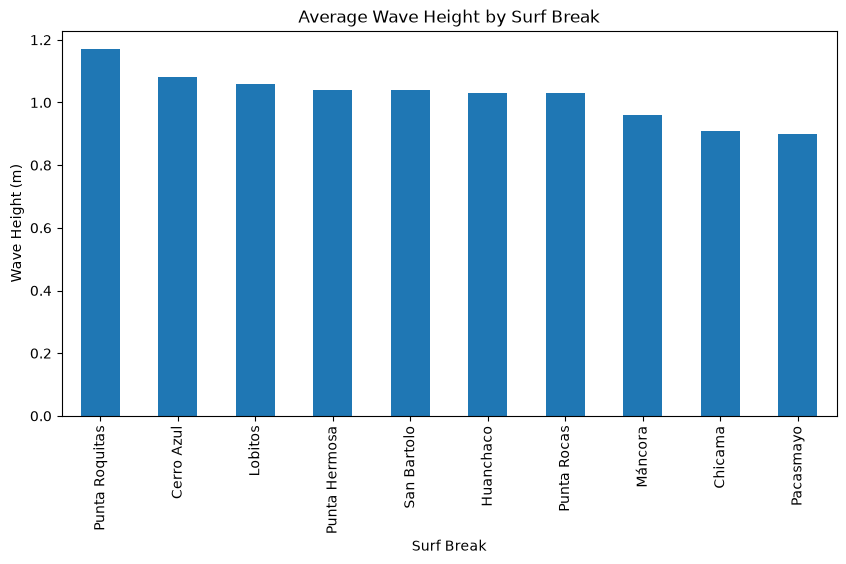

In [10]:
beach_summary["avg_wave_height"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Wave Height by Surf Break",
    ylabel="Wave Height (m)",
    xlabel="Surf Break"
);

In [11]:
df = pd.read_csv("../data/raw/marine_data.csv")

In [12]:
df = pd.read_csv("../data/raw/marine_data.csv")

In [13]:
df["beach_name"].unique()

<StringArray>
[       'Máncora',        'Lobitos',        'Chicama',      'Huanchaco',
      'Pacasmayo', 'Punta Roquitas',  'Punta Hermosa',    'Punta Rocas',
    'San Bartolo',     'Cerro Azul']
Length: 10, dtype: str

In [14]:
import pandas as pd

df = pd.read_csv("../data/raw/marine_data.csv")

df["beach_name"].unique()

<StringArray>
[       'Máncora',        'Lobitos',        'Chicama',      'Huanchaco',
      'Pacasmayo', 'Punta Roquitas',  'Punta Hermosa',    'Punta Rocas',
    'San Bartolo',     'Cerro Azul']
Length: 10, dtype: str

In [15]:
beach_summary = (
    df.groupby("beach_name")
    .agg(
        avg_wave_height=("wave_height", "mean"),
        max_wave_height=("wave_height", "max"),
        avg_wave_period=("wave_period", "mean"),
        max_wave_period=("wave_period", "max"),
    )
    .round(2)
)

beach_summary

,avg_wave_height,max_wave_height,avg_wave_period,max_wave_period
beach_name,,,,
Cerro Azul,1.08,1.28,10.23,11.15
Chicama,0.91,1.00,9.88,10.75
Huanchaco,1.03,1.12,10.11,10.80
Lobitos,1.06,1.18,8.12,9.55
Máncora,0.96,1.16,7.59,10.15
Pacasmayo,0.90,1.04,8.32,9.25
Punta Hermosa,1.04,1.16,10.45,11.05
Punta Rocas,1.03,1.16,10.60,11.10
Punta Roquitas,1.17,1.30,9.93,10.45


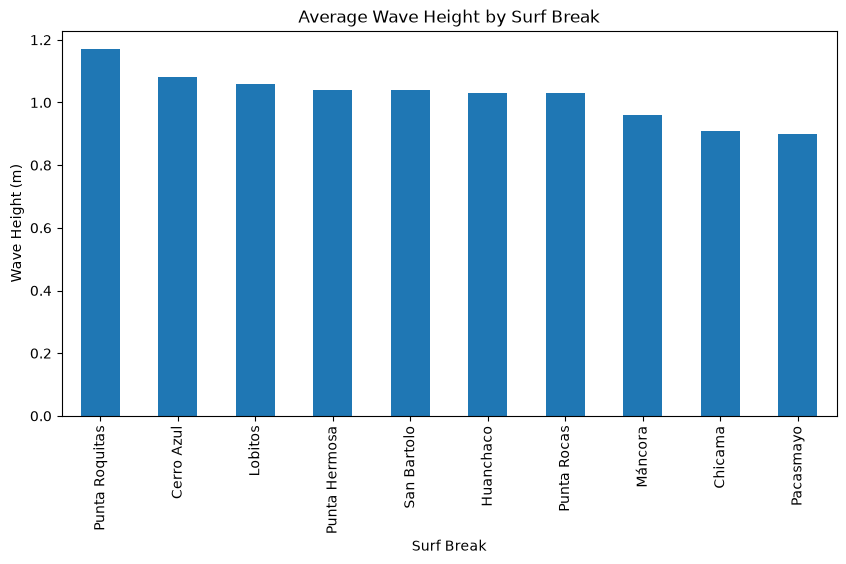

In [16]:
beach_summary["avg_wave_height"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Wave Height by Surf Break",
    ylabel="Wave Height (m)",
    xlabel="Surf Break"
);

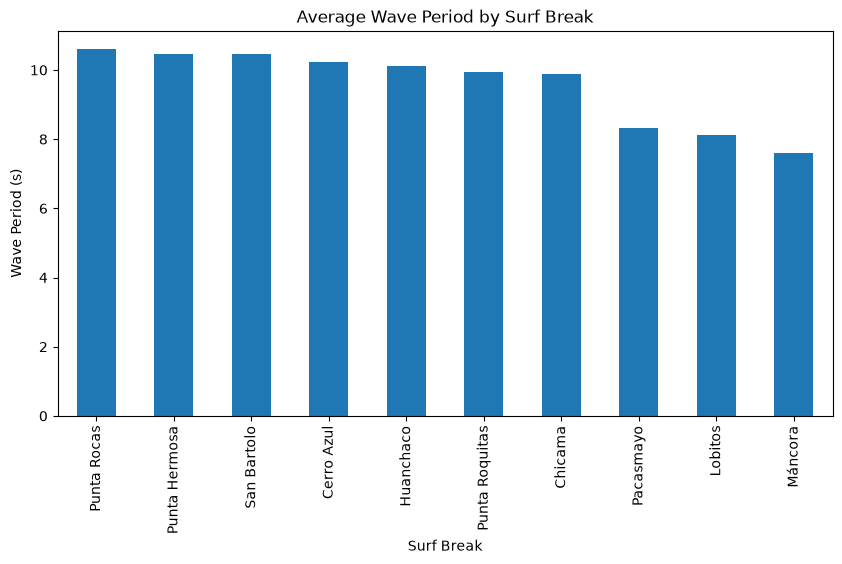

In [17]:
beach_summary["avg_wave_period"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Wave Period by Surf Break",
    ylabel="Wave Period (s)",
    xlabel="Surf Break"
);

In [18]:
height_min = beach_summary["avg_wave_height"].min()
height_max = beach_summary["avg_wave_height"].max()

period_min = beach_summary["avg_wave_period"].min()
period_max = beach_summary["avg_wave_period"].max()

beach_summary["height_score"] = (
    (beach_summary["avg_wave_height"] - height_min)
    / (height_max - height_min)
    * 100
)

beach_summary["period_score"] = (
    (beach_summary["avg_wave_period"] - period_min)
    / (period_max - period_min)
    * 100
)

beach_summary["wave_quality_score"] = (
    beach_summary["height_score"] * 0.5
    + beach_summary["period_score"] * 0.5
).round(1)

beach_summary.sort_values("wave_quality_score", ascending=False)

,avg_wave_height,max_wave_height,avg_wave_period,max_wave_period,height_score,period_score,wave_quality_score
beach_name,,,,,,,
Punta Roquitas,1.17,1.30,9.93,10.45,100.000000,77.740864,88.9
Cerro Azul,1.08,1.28,10.23,11.15,66.666667,87.707641,77.2
Punta Rocas,1.03,1.16,10.60,11.10,48.148148,100.000000,74.1
San Bartolo,1.04,1.16,10.45,11.05,51.851852,95.016611,73.4
Punta Hermosa,1.04,1.16,10.45,11.05,51.851852,95.016611,73.4
Huanchaco,1.03,1.12,10.11,10.80,48.148148,83.720930,65.9
Chicama,0.91,1.00,9.88,10.75,3.703704,76.079734,39.9
Lobitos,1.06,1.18,8.12,9.55,59.259259,17.607973,38.4
Pacasmayo,0.90,1.04,8.32,9.25,0.000000,24.252492,12.1


In [19]:
def wave_height_score(height):
    if height < 0.3:
        return 10
    elif height < 0.6:
        return 35
    elif height < 1.0:
        return 65
    elif height < 1.5:
        return 85
    elif height < 2.5:
        return 100
    else:
        return 70

In [20]:
for height in [0.2, 0.5, 0.8, 1.2, 1.8, 3.0]:
    print(height, wave_height_score(height))

0.2 10
0.5 35
0.8 65
1.2 85
1.8 100
3.0 70


In [21]:
def wave_period_score(period):
    if period < 6:
        return 10
    elif period < 8:
        return 35
    elif period < 10:
        return 65
    elif period < 14:
        return 85
    else:
        return 100

In [22]:
for period in [5, 7, 9, 11, 13, 16]:
    print(period, wave_period_score(period))

5 10
7 35
9 65
11 85
13 85
16 100


In [23]:
def wind_speed_score(wind_speed):
    if wind_speed < 5:
        return 100
    elif wind_speed < 10:
        return 85
    elif wind_speed < 15:
        return 65
    elif wind_speed < 20:
        return 40
    elif wind_speed < 25:
        return 20
    else:
        return 5

In [24]:
for wind in [3, 7, 12, 17, 22, 28]:
    print(wind, wind_speed_score(wind))

3 100
7 85
12 65
17 40
22 20
28 5


In [25]:
def angular_distance(direction_1, direction_2):
    difference = abs(direction_1 - direction_2)
    return min(difference, 360 - difference)

In [26]:
print(angular_distance(225, 225))
print(angular_distance(225, 180))
print(angular_distance(350, 10))
print(angular_distance(10, 350))

0
45
20
20


In [27]:
def swell_direction_score(actual_direction, preferred_direction):
    distance = angular_distance(actual_direction, preferred_direction)

    score = max(100 - (distance / 90) * 100, 0)

    return round(score, 1)

In [28]:
tests = [0, 10, 30, 45, 90, 135]

for distance in tests:
    score = swell_direction_score(
        actual_direction=225 + distance,
        preferred_direction=225
    )
    print(f"Distance: {distance}° → Score: {score}")

Distance: 0° → Score: 100.0
Distance: 10° → Score: 88.9
Distance: 30° → Score: 66.7
Distance: 45° → Score: 50.0
Distance: 90° → Score: 0.0
Distance: 135° → Score: 0


In [29]:
def calculate_surf_score(
    wave_height,
    wave_period,
    wind_speed,
    wave_direction,
    preferred_swell_direction
):
    height_score = wave_height_score(wave_height)
    period_score = wave_period_score(wave_period)
    wind_score = wind_speed_score(wind_speed)
    direction_score = swell_direction_score(
        wave_direction,
        preferred_swell_direction
    )

    score = (
        height_score * 0.30
        + period_score * 0.30
        + wind_score * 0.20
        + direction_score * 0.20
    )

    return round(score, 1)

In [30]:
score = calculate_surf_score(
    wave_height=1.2,
    wave_period=12,
    wind_speed=7,
    wave_direction=220,
    preferred_swell_direction=225
)

print(f"Surf Score: {score}/100")

Surf Score: 86.9/100


In [31]:
beaches = pd.read_csv("../data/beaches.csv")

beaches = beaches.rename(columns={"id": "beach_id"})

df = df.merge(
    beaches[
        [
            "beach_id",
            "preferred_swell_direction_deg",
            "swell_direction_tolerance_deg"
        ]
    ],
    on="beach_id",
    how="left"
)

df.head()

,time,wave_height,wave_period,wave_direction,wind_wave_height,swell_wave_height,swell_wave_period,swell_wave_direction,wind_speed_10m,wind_direction_10m,beach_id,beach_name,preferred_swell_direction_deg,swell_direction_tolerance_deg
0,2026-08-23T00:00,0.92,7.90,224,0.38,0.46,9.70,227,7.9,177,1,Máncora,315,45
1,2026-08-23T01:00,0.88,8.05,225,0.36,0.46,10.05,227,9.3,188,1,Máncora,315,45
2,2026-08-23T02:00,0.88,8.05,224,0.40,0.46,10.10,227,10.5,192,1,Máncora,315,45
3,2026-08-23T03:00,0.88,8.00,223,0.42,0.44,10.00,227,11.9,185,1,Máncora,315,45
4,2026-08-23T04:00,0.88,7.95,222,0.46,0.44,9.90,227,13.6,186,1,Máncora,315,45


In [32]:
df[
    [
        "beach_name",
        "wave_direction",
        "preferred_swell_direction_deg",
        "swell_direction_tolerance_deg"
    ]
].head(10)

,beach_name,wave_direction,preferred_swell_direction_deg,swell_direction_tolerance_deg
0,Máncora,224,315,45
1,Máncora,225,315,45
2,Máncora,224,315,45
3,Máncora,223,315,45
4,Máncora,222,315,45
5,Máncora,221,315,45
6,Máncora,221,315,45
7,Máncora,220,315,45
8,Máncora,220,315,45
9,Máncora,219,315,45


In [33]:
df["surf_score"] = df.apply(
    lambda row: calculate_surf_score(
        wave_height=row["wave_height"],
        wave_period=row["wave_period"],
        wind_speed=row["wind_speed_10m"],
        wave_direction=row["wave_direction"],
        preferred_swell_direction=row["preferred_swell_direction_deg"]
    ),
    axis=1
)

df[[
    "time",
    "beach_name",
    "wave_height",
    "wave_period",
    "wave_direction",
    "wind_wave_height",
    "surf_score"
]].head(10)

,time,beach_name,wave_height,wave_period,wave_direction,wind_wave_height,surf_score
0,2026-08-23T00:00,Máncora,0.92,7.90,224,0.38,47.0
1,2026-08-23T01:00,Máncora,0.88,8.05,225,0.36,56.0
2,2026-08-23T02:00,Máncora,0.88,8.05,224,0.40,52.0
3,2026-08-23T03:00,Máncora,0.88,8.00,223,0.42,52.0
4,2026-08-23T04:00,Máncora,0.88,7.95,222,0.46,43.0
5,2026-08-23T05:00,Máncora,0.88,7.90,221,0.48,43.0
6,2026-08-23T06:00,Máncora,0.90,7.90,221,0.50,38.0
7,2026-08-23T07:00,Máncora,0.90,7.85,220,0.52,34.0
8,2026-08-23T08:00,Máncora,0.92,7.85,220,0.54,34.0
9,2026-08-23T09:00,Máncora,0.92,7.85,219,0.56,38.0


In [34]:
df[
    [
        "time",
        "beach_name",
        "wave_height",
        "wave_period",
        "wind_speed_10m",
        "wave_direction",
        "surf_score"
    ]
].head(10)


,time,beach_name,wave_height,wave_period,wind_speed_10m,wave_direction,surf_score
0,2026-08-23T00:00,Máncora,0.92,7.90,7.9,224,47.0
1,2026-08-23T01:00,Máncora,0.88,8.05,9.3,225,56.0
2,2026-08-23T02:00,Máncora,0.88,8.05,10.5,224,52.0
3,2026-08-23T03:00,Máncora,0.88,8.00,11.9,223,52.0
4,2026-08-23T04:00,Máncora,0.88,7.95,13.6,222,43.0
5,2026-08-23T05:00,Máncora,0.88,7.90,14.5,221,43.0
6,2026-08-23T06:00,Máncora,0.90,7.90,16.6,221,38.0
7,2026-08-23T07:00,Máncora,0.90,7.85,21.8,220,34.0
8,2026-08-23T08:00,Máncora,0.92,7.85,21.4,220,34.0
9,2026-08-23T09:00,Máncora,0.92,7.85,18.9,219,38.0


In [35]:
df = pd.read_csv("../data/raw/marine_data.csv")

df[
    [
        "time",
        "beach_name",
        "wave_height",
        "wave_period",
        "wave_direction",
        "wind_speed_10m",
        "wind_direction_10m"
    ]
].head(10)

,time,beach_name,wave_height,wave_period,wave_direction,wind_speed_10m,wind_direction_10m
0,2026-08-23T00:00,Máncora,0.92,7.90,224,7.9,177
1,2026-08-23T01:00,Máncora,0.88,8.05,225,9.3,188
2,2026-08-23T02:00,Máncora,0.88,8.05,224,10.5,192
3,2026-08-23T03:00,Máncora,0.88,8.00,223,11.9,185
4,2026-08-23T04:00,Máncora,0.88,7.95,222,13.6,186
5,2026-08-23T05:00,Máncora,0.88,7.90,221,14.5,186
6,2026-08-23T06:00,Máncora,0.90,7.90,221,16.6,186
7,2026-08-23T07:00,Máncora,0.90,7.85,220,21.8,182
8,2026-08-23T08:00,Máncora,0.92,7.85,220,21.4,173
9,2026-08-23T09:00,Máncora,0.92,7.85,219,18.9,176


In [36]:
beaches = pd.read_csv("../data/beaches.csv")

beaches = beaches.rename(columns={"id": "beach_id"})

df = df.merge(
    beaches[
        [
            "beach_id",
            "preferred_swell_direction_deg",
            "swell_direction_tolerance_deg"
        ]
    ],
    on="beach_id",
    how="left"
)

df[
    [
        "beach_name",
        "wave_direction",
        "preferred_swell_direction_deg"
    ]
].head(10)

,beach_name,wave_direction,preferred_swell_direction_deg
0,Máncora,224,315
1,Máncora,225,315
2,Máncora,224,315
3,Máncora,223,315
4,Máncora,222,315
5,Máncora,221,315
6,Máncora,221,315
7,Máncora,220,315
8,Máncora,220,315
9,Máncora,219,315


In [37]:
df["surf_score"] = df.apply(
    lambda row: calculate_surf_score(
        wave_height=row["wave_height"],
        wave_period=row["wave_period"],
        wind_speed=row["wind_speed_10m"],
        wave_direction=row["wave_direction"],
        preferred_swell_direction=row["preferred_swell_direction_deg"]
    ),
    axis=1
)

df[
    [
        "time",
        "beach_name",
        "wave_height",
        "wave_period",
        "wind_speed_10m",
        "wave_direction",
        "surf_score"
    ]
].head(10)

,time,beach_name,wave_height,wave_period,wind_speed_10m,wave_direction,surf_score
0,2026-08-23T00:00,Máncora,0.92,7.90,7.9,224,47.0
1,2026-08-23T01:00,Máncora,0.88,8.05,9.3,225,56.0
2,2026-08-23T02:00,Máncora,0.88,8.05,10.5,224,52.0
3,2026-08-23T03:00,Máncora,0.88,8.00,11.9,223,52.0
4,2026-08-23T04:00,Máncora,0.88,7.95,13.6,222,43.0
5,2026-08-23T05:00,Máncora,0.88,7.90,14.5,221,43.0
6,2026-08-23T06:00,Máncora,0.90,7.90,16.6,221,38.0
7,2026-08-23T07:00,Máncora,0.90,7.85,21.8,220,34.0
8,2026-08-23T08:00,Máncora,0.92,7.85,21.4,220,34.0
9,2026-08-23T09:00,Máncora,0.92,7.85,18.9,219,38.0


In [38]:
beach_scores = (
    df.groupby("beach_name")
    .agg(
        avg_surf_score=("surf_score", "mean"),
        max_surf_score=("surf_score", "max"),
        min_surf_score=("surf_score", "min")
    )
    .round(1)
    .sort_values("avg_surf_score", ascending=False)
)

beach_scores

,avg_surf_score,max_surf_score,min_surf_score
beach_name,,,
Punta Hermosa,78.0,85.9,67.2
Punta Rocas,77.8,85.9,68.1
Huanchaco,77.5,87.9,69.4
Cerro Azul,76.5,83.6,67.4
San Bartolo,74.6,82.9,67.2
Punta Roquitas,74.1,84.1,65.9
Chicama,69.2,79.0,56.6
Lobitos,60.5,69.0,52.3
Pacasmayo,56.0,64.7,43.0


In [39]:
df[
    [
        "beach_name",
        "wind_speed_10m",
        "wind_direction_10m"
    ]
].head(20)

,beach_name,wind_speed_10m,wind_direction_10m
0,Máncora,7.9,177
1,Máncora,9.3,188
2,Máncora,10.5,192
3,Máncora,11.9,185
4,Máncora,13.6,186
5,Máncora,14.5,186
6,Máncora,16.6,186
7,Máncora,21.8,182
8,Máncora,21.4,173
9,Máncora,18.9,176


In [40]:
wind_summary = (
    df.groupby("beach_name")
    .agg(
        avg_wind_speed=("wind_speed_10m", "mean"),
        max_wind_speed=("wind_speed_10m", "max"),
        min_wind_direction=("wind_direction_10m", "min"),
        max_wind_direction=("wind_direction_10m", "max")
    )
    .round(1)
)

wind_summary

,avg_wind_speed,max_wind_speed,min_wind_direction,max_wind_direction
beach_name,,,,
Cerro Azul,11.8,18.5,79,268
Chicama,11.5,24.9,6,349
Huanchaco,10.8,18.8,81,262
Lobitos,22.5,31.9,159,215
Máncora,19.4,32.8,60,354
Pacasmayo,18.5,27.5,129,212
Punta Hermosa,7.9,16.3,16,212
Punta Rocas,9.8,18.0,87,217
Punta Roquitas,12.0,17.4,106,199


In [41]:
beaches = pd.read_csv("../data/beaches.csv")

beaches = beaches.rename(columns={"id": "beach_id"})

df = df.drop(
    columns=[
        "preferred_swell_direction_deg",
        "swell_direction_tolerance_deg"
    ],
    errors="ignore"
)

df = df.merge(
    beaches[
        [
            "beach_id",
            "preferred_swell_direction_deg",
            "swell_direction_tolerance_deg",
            "preferred_wind_direction_deg",
            "wind_direction_tolerance_deg"
        ]
    ],
    on="beach_id",
    how="left"
)

df[
    [
        "beach_name",
        "preferred_swell_direction_deg",
        "preferred_wind_direction_deg"
    ]
].drop_duplicates()

,beach_name,preferred_swell_direction_deg,preferred_wind_direction_deg
0,Máncora,315,112
72,Lobitos,225,112
144,Chicama,225,135
216,Huanchaco,180,157
288,Pacasmayo,225,45
360,Punta Roquitas,225,45
432,Punta Hermosa,180,45
504,Punta Rocas,225,90
576,San Bartolo,180,67
648,Cerro Azul,225,67


In [42]:
def wind_direction_score(actual_direction, preferred_direction):
    distance = angular_distance(
        actual_direction,
        preferred_direction
    )

    score = max(100 - (distance / 90) * 100, 0)

    return round(score, 1)

In [43]:
tests = [0, 15, 30, 45, 60, 90]

for distance in tests:
    score = wind_direction_score(
        actual_direction=45 + distance,
        preferred_direction=45
    )
    print(f"Distance: {distance}° → Score: {score}")

Distance: 0° → Score: 100.0
Distance: 15° → Score: 83.3
Distance: 30° → Score: 66.7
Distance: 45° → Score: 50.0
Distance: 60° → Score: 33.3
Distance: 90° → Score: 0.0


In [46]:
def calculate_surf_score(
    wave_height,
    wave_period,
    wind_speed,
    wave_direction,
    preferred_swell_direction,
    wind_direction,
    preferred_wind_direction
):
    height_score = wave_height_score(wave_height)

    period_score = wave_period_score(wave_period)

    wind_speed_score_value = wind_speed_score(wind_speed)

    swell_direction_score_value = swell_direction_score(
        wave_direction,
        preferred_swell_direction
    )

    wind_direction_score_value = wind_direction_score(
        wind_direction,
        preferred_wind_direction
    )

    score = (
        height_score * 0.25
        + period_score * 0.25
        + wind_speed_score_value * 0.15
        + swell_direction_score_value * 0.15
        + wind_direction_score_value * 0.20
    )

    return round(score, 1)

In [47]:
score = calculate_surf_score(
    wave_height=1.2,
    wave_period=12,
    wind_speed=7,
    wave_direction=220,
    preferred_swell_direction=225,
    wind_direction=45,
    preferred_wind_direction=45
)

print(f"Surf Score: {score}/100")

Surf Score: 89.4/100


In [48]:
df["surf_score"] = df.apply(
    lambda row: calculate_surf_score(
        wave_height=row["wave_height"],
        wave_period=row["wave_period"],
        wind_speed=row["wind_speed_10m"],
        wave_direction=row["wave_direction"],
        preferred_swell_direction=row["preferred_swell_direction_deg"],
        wind_direction=row["wind_direction_10m"],
        preferred_wind_direction=row["preferred_wind_direction_deg"]
    ),
    axis=1
)

In [49]:
beach_scores = (
    df.groupby("beach_name")
    .agg(
        avg_surf_score=("surf_score", "mean"),
        max_surf_score=("surf_score", "max"),
        min_surf_score=("surf_score", "min")
    )
    .round(1)
    .sort_values("avg_surf_score", ascending=False)
)

beach_scores

,avg_surf_score,max_surf_score,min_surf_score
beach_name,,,
Huanchaco,74.3,85.7,65.7
Punta Rocas,67.9,85.5,54.8
Punta Hermosa,66.2,87.8,54.2
Cerro Azul,64.8,82.1,55.0
San Bartolo,62.7,79.5,54.2
Chicama,62.3,80.1,51.6
Punta Roquitas,61.0,71.3,53.2
Lobitos,53.1,62.7,42.3
Pacasmayo,45.1,52.8,34.8


In [50]:
output_file = "../data/processed/surf_scores.csv"

df.to_csv(output_file, index=False)

print(f"Saved {len(df)} rows to {output_file}")

Saved 720 rows to ../data/processed/surf_scores.csv


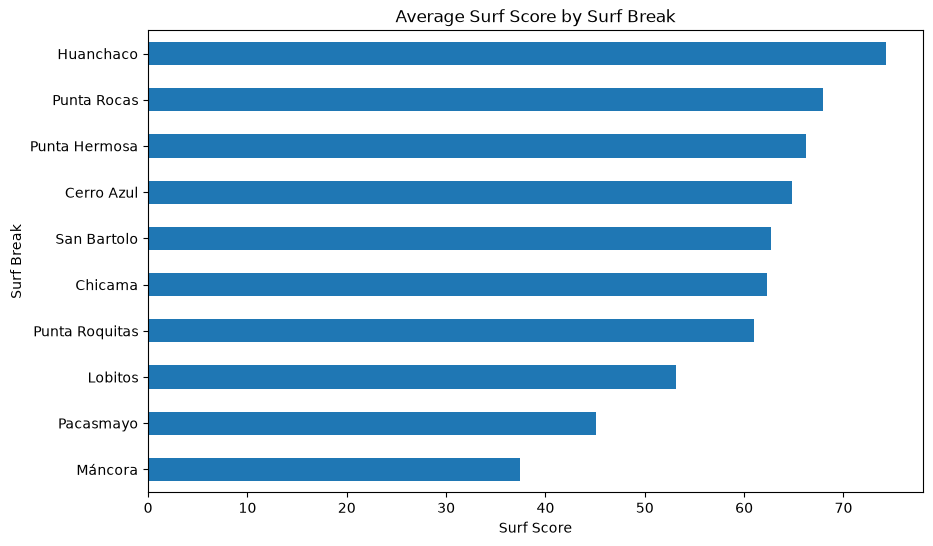

In [51]:
beach_scores["avg_surf_score"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(10, 6),
    title="Average Surf Score by Surf Break",
    xlabel="Surf Score",
    ylabel="Surf Break"
);

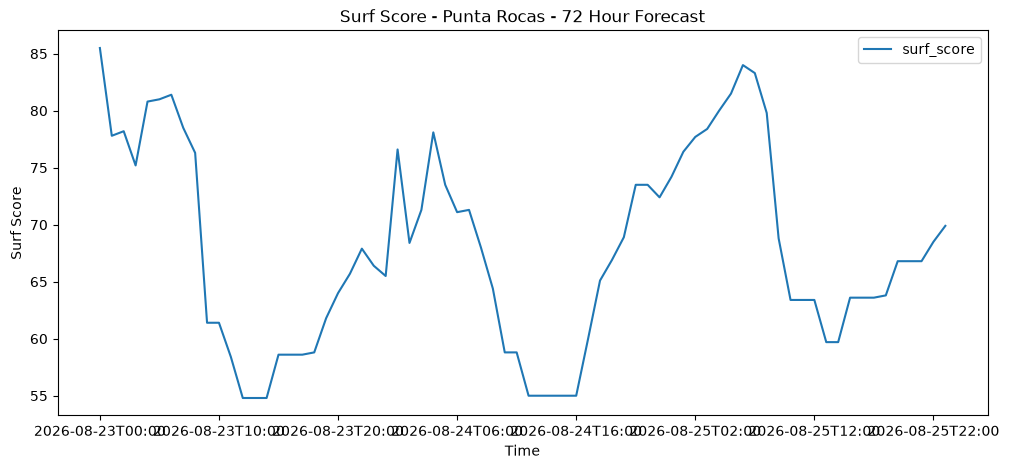

In [52]:
punta_rocas = df[df["beach_name"] == "Punta Rocas"].copy()

punta_rocas.plot(
    x="time",
    y="surf_score",
    kind="line",
    figsize=(12, 5),
    title="Surf Score - Punta Rocas - 72 Hour Forecast",
    xlabel="Time",
    ylabel="Surf Score"
);

In [53]:
best_times = (
    punta_rocas[
        [
            "time",
            "surf_score",
            "wave_height",
            "wave_period",
            "wave_direction",
            "wind_speed_10m",
            "wind_direction_10m"
        ]
    ]
    .sort_values("surf_score", ascending=False)
    .head(10)
)

best_times

,time,surf_score,wave_height,wave_period,wave_direction,wind_speed_10m,wind_direction_10m
504,2026-08-23T00:00,85.5,1.02,10.60,202,3.7,104
558,2026-08-25T06:00,84.0,1.12,10.05,202,5.7,101
559,2026-08-25T07:00,83.3,1.14,10.05,202,6.9,104
557,2026-08-25T05:00,81.5,1.12,10.05,202,6.4,112
510,2026-08-23T06:00,81.4,0.98,10.70,202,5.0,90
509,2026-08-23T05:00,81.0,0.98,10.70,202,5.0,88
508,2026-08-23T04:00,80.8,0.98,10.70,202,6.0,87
556,2026-08-25T04:00,80.0,1.10,10.05,202,6.4,119
560,2026-08-25T08:00,79.8,1.14,10.05,202,7.7,120
511,2026-08-23T07:00,78.5,0.98,10.70,202,7.8,103


In [54]:
display(
    best_times[
        [
            "time",
            "surf_score",
            "wave_height",
            "wave_period",
            "wave_direction",
            "wind_speed_10m",
            "wind_direction_10m"
        ]
    ].rename(
        columns={
            "time": "Time",
            "surf_score": "Surf Score",
            "wave_height": "Wave Height (m)",
            "wave_period": "Wave Period (s)",
            "wave_direction": "Swell Direction (°)",
            "wind_speed_10m": "Wind Speed (km/h)",
            "wind_direction_10m": "Wind Direction (°)"
        }
    ).reset_index(drop=True)
)

,Time,Surf Score,Wave Height (m),Wave Period (s),Swell Direction (°),Wind Speed (km/h),Wind Direction (°)
0,2026-08-23T00:00,85.5,1.02,10.60,202,3.7,104
1,2026-08-25T06:00,84.0,1.12,10.05,202,5.7,101
2,2026-08-25T07:00,83.3,1.14,10.05,202,6.9,104
3,2026-08-25T05:00,81.5,1.12,10.05,202,6.4,112
4,2026-08-23T06:00,81.4,0.98,10.70,202,5.0,90
5,2026-08-23T05:00,81.0,0.98,10.70,202,5.0,88
6,2026-08-23T04:00,80.8,0.98,10.70,202,6.0,87
7,2026-08-25T04:00,80.0,1.10,10.05,202,6.4,119
8,2026-08-25T08:00,79.8,1.14,10.05,202,7.7,120
9,2026-08-23T07:00,78.5,0.98,10.70,202,7.8,103


In [55]:
def show_beach_forecast(beach_name):
    beach = df[df["beach_name"] == beach_name].copy()

    print(f"Surf Forecast: {beach_name}")
    print(f"Average Surf Score: {beach['surf_score'].mean():.1f}")
    print(f"Best Surf Score: {beach['surf_score'].max():.1f}")

    beach.plot(
        x="time",
        y="surf_score",
        kind="line",
        figsize=(12, 5),
        title=f"Surf Score - {beach_name} - 72 Hour Forecast",
        xlabel="Time",
        ylabel="Surf Score"
    )

Surf Forecast: Punta Rocas
Average Surf Score: 67.9
Best Surf Score: 85.5


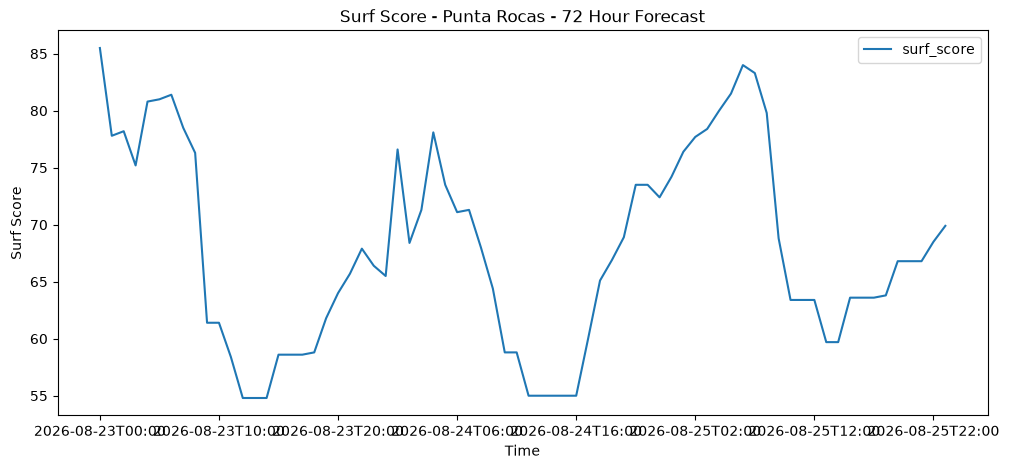

In [56]:
show_beach_forecast("Punta Rocas")

In [57]:
import ipywidgets as widgets
from IPython.display import display

beach_selector = widgets.Dropdown(
    options=sorted(df["beach_name"].unique()),
    description="Playa:"
)

display(beach_selector)

Dropdown(description='Playa:', options=('Cerro Azul', 'Chicama', 'Huanchaco', 'Lobitos', 'Máncora', 'Pacasmayo…

In [58]:
def update_beach_forecast(change):
    if change["name"] == "value":
        show_beach_forecast(change["new"])

widgets.interactive(
    show_beach_forecast,
    beach_name=beach_selector
)

interactive(children=(Dropdown(description='Playa:', index=7, options=('Cerro Azul', 'Chicama', 'Huanchaco', '…

In [59]:
def show_beach_conditions(beach_name):
    beach = df[df["beach_name"] == beach_name].copy()

    conditions = beach[
        [
            "time",
            "surf_score",
            "wave_height",
            "wave_period",
            "wave_direction",
            "wind_speed_10m",
            "wind_direction_10m"
        ]
    ].copy()

    conditions = conditions.rename(
        columns={
            "time": "Time",
            "surf_score": "Surf Score",
            "wave_height": "Wave Height (m)",
            "wave_period": "Wave Period (s)",
            "wave_direction": "Swell Direction (°)",
            "wind_speed_10m": "Wind Speed (km/h)",
            "wind_direction_10m": "Wind Direction (°)"
        }
    )

    return conditions.reset_index(drop=True)

In [60]:
show_beach_conditions("Punta Rocas")

,Time,Surf Score,Wave Height (m),Wave Period (s),Swell Direction (°),Wind Speed (km/h),Wind Direction (°)
0,2026-08-23T00:00,85.5,1.02,10.60,202,3.7,104
1,2026-08-23T01:00,77.8,1.00,10.65,202,8.6,129
2,2026-08-23T02:00,78.2,1.00,10.70,202,7.8,127
3,2026-08-23T03:00,75.2,0.98,10.70,202,6.9,118
4,2026-08-23T04:00,80.8,0.98,10.70,202,6.0,87
...,...,...,...,...,...,...,...
67,2026-08-25T19:00,66.8,1.14,10.35,204,9.6,189
68,2026-08-25T20:00,66.8,1.14,10.40,204,8.3,184
69,2026-08-25T21:00,66.8,1.12,10.45,204,7.2,180
70,2026-08-25T22:00,68.5,1.12,10.45,204,8.0,172


In [61]:
def best_surf_times(beach_name, n=5):
    beach = df[df["beach_name"] == beach_name].copy()

    best = (
        beach[
            [
                "time",
                "surf_score",
                "wave_height",
                "wave_period",
                "wave_direction",
                "wind_speed_10m",
                "wind_direction_10m"
            ]
        ]
        .sort_values("surf_score", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    return best

In [62]:
best_surf_times("Punta Rocas")

,time,surf_score,wave_height,wave_period,wave_direction,wind_speed_10m,wind_direction_10m
0,2026-08-23T00:00,85.5,1.02,10.60,202,3.7,104
1,2026-08-25T06:00,84.0,1.12,10.05,202,5.7,101
2,2026-08-25T07:00,83.3,1.14,10.05,202,6.9,104
3,2026-08-25T05:00,81.5,1.12,10.05,202,6.4,112
4,2026-08-23T06:00,81.4,0.98,10.70,202,5.0,90
